# Final comparison

All three models trained and evaluated. This notebook loads their scores, puts everything in one table, plots the ROC curves together, and draws conclusions. This is the main result of the project.

## Load all scores

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve)
import os

iso = np.load('../uci-outputs/iso_scores.npz')
ae  = np.load('../uci-outputs/ae_scores.npz')
cnn = np.load('../uci-outputs/cnn_scores.npz')

# all three share the same y_test
y_test = iso['y_test']

iso_scores = iso['test_scores']
ae_scores  = ae['test_scores']
cnn_scores = cnn['test_scores']

print("test set size:", len(y_test))
print("empty:", (y_test==0).sum(), " occupied:", (y_test==1).sum())

test set size: 1551
empty: 452  occupied: 1099


## Recompute thresholds and predictions

Need the val scores to recompute thresholds here. Loading prepared data and rerunning the threshold step for each model so everything is in one place.

In [2]:
HERE      = os.path.abspath('')
DATA_PATH = os.path.join(HERE, '../uci-data/prepared.npz')

data       = np.load(DATA_PATH)
X_val      = data['X_val']
train_mean = data['train_mean']
train_std  = data['train_std']

def norm(x): return (x - train_mean) / (train_std + 1e-8)

# isolation forest val scores
from sklearn.ensemble import IsolationForest

def window_features(windows):
    feats = []
    for w in windows:
        f = []
        for s in range(w.shape[1]):
            sig = w[:, s]
            f += [sig.mean(), sig.std(), sig.min(), sig.max(), sig.max()-sig.min()]
        feats.append(f)
    return np.array(feats)

X_train = data['X_train']
F_train = window_features(X_train)
F_val   = window_features(X_val)

f_mean = F_train.mean(axis=0)
f_std  = F_train.std(axis=0)
F_train_n = (F_train - f_mean) / (f_std + 1e-8)
F_val_n   = (F_val   - f_mean) / (f_std + 1e-8)

iso_model = IsolationForest(n_estimators=200, contamination=0.01, random_state=42)
iso_model.fit(F_train_n)
iso_val_scores = -iso_model.score_samples(F_val_n)
iso_thresh = np.percentile(iso_val_scores, 95)

# mlp val scores
import torch
import torch.nn as nn

class MLPAutoencoder(nn.Module):
    def __init__(self, in_dim=60):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 16), nn.ReLU(),
            nn.Linear(16, 32), nn.ReLU(),
            nn.Linear(32, in_dim),
        )
    def forward(self, x): return self.decoder(self.encoder(x))

Xva_mlp = torch.tensor(norm(X_val).reshape(len(X_val), -1), dtype=torch.float32)
mlp = MLPAutoencoder()
torch.manual_seed(42)
opt = torch.optim.Adam(mlp.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
Xtr_mlp = torch.tensor(norm(X_train).reshape(len(X_train), -1), dtype=torch.float32)
for _ in range(100):
    mlp.train(); opt.zero_grad()
    loss = loss_fn(mlp(Xtr_mlp), Xtr_mlp)
    loss.backward(); opt.step()
mlp.eval()
with torch.no_grad():
    ae_val_scores = ((Xva_mlp - mlp(Xva_mlp))**2).mean(dim=1).numpy()
ae_thresh = np.percentile(ae_val_scores, 95)

# cnn val scores
class CNNAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(2, 16, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(16, 8, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool1d(2),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(8, 16, kernel_size=2, stride=2), nn.ReLU(),
            nn.Conv1d(16, 2, kernel_size=3, padding=1),
        )
    def forward(self, x): return self.decoder(self.encoder(x))

Xva_cnn = torch.tensor(norm(X_val), dtype=torch.float32).permute(0,2,1)
Xtr_cnn = torch.tensor(norm(X_train), dtype=torch.float32).permute(0,2,1)
torch.manual_seed(42)
cnn_model = CNNAutoencoder()
opt2 = torch.optim.Adam(cnn_model.parameters(), lr=1e-3)
for _ in range(100):
    cnn_model.train(); opt2.zero_grad()
    loss = loss_fn(cnn_model(Xtr_cnn), Xtr_cnn)
    loss.backward(); opt2.step()
cnn_model.eval()
with torch.no_grad():
    cnn_val_scores = ((Xva_cnn - cnn_model(Xva_cnn))**2).mean(dim=(1,2)).numpy()
cnn_thresh = np.percentile(cnn_val_scores, 95)

print("thresholds iso:", round(iso_thresh,4),
      " mlp:", round(ae_thresh,4),
      " cnn:", round(cnn_thresh,4))

thresholds iso: 0.6958  mlp: 0.8189  cnn: 0.1671


## Results table

In [3]:
models = {
    'Isolation Forest': (iso_scores, iso_thresh),
    'MLP Autoencoder' : (ae_scores,  ae_thresh),
    'CNN Autoencoder' : (cnn_scores, cnn_thresh),
}

print(f"{'Model':<22} {'Precision':>10} {'Recall':>8} {'F1':>8} {'ROC-AUC':>9}")
print("-" * 62)
results = {}
for name, (scores, thresh) in models.items():
    y_pred = (scores > thresh).astype(int)
    p = precision_score(y_test, y_pred)
    r = recall_score(y_test, y_pred)
    f = f1_score(y_test, y_pred)
    a = roc_auc_score(y_test, scores)
    results[name] = (p, r, f, a)
    print(f"{name:<22} {p:>10.3f} {r:>8.3f} {f:>8.3f} {a:>9.3f}")

Model                   Precision   Recall       F1   ROC-AUC
--------------------------------------------------------------
Isolation Forest            0.953    0.843    0.895     0.928
MLP Autoencoder             0.948    0.396    0.558     0.884
CNN Autoencoder             0.858    0.988    0.919     0.707


the numbers tell two different stories depending on which metric you look at.

on f1, cnn wins (0.919) and mlp is the weakest (0.561). on roc-auc, isolation forest wins (0.928) and cnn is the weakest (0.707). this split happens because f1 depends on where you set the threshold and roc-auc doesn't  they measure different things.

mlp is consistently the weakest on both metrics. flattening the 30x2 window into 60 unordered values loses the time structure and that clearly hurts. many occupied windows ended up with low reconstruction error because their average signal values were similar to empty windows.

isolation forest is the most balanced strong on both f1 and roc-auc, no clear weakness. for a method that uses hand-crafted summary features and no neural network at all, this is a strong result and the hardest baseline to justify beating.

cnn has the highest recall of all three (0.988, misses only 13 occupied windows out of 1099) but pays for it with more false alarms (179 vs 46 for isolation forest). its roc-auc being the lowest suggests the raw scores don't separate the classes cleanly the model is confident but not well-calibrated.

## ROC curves

All three on one plot. ROC curve shows how precision and recall trade off at every possible threshold, so it's a fairer comparison than a single threshold point.

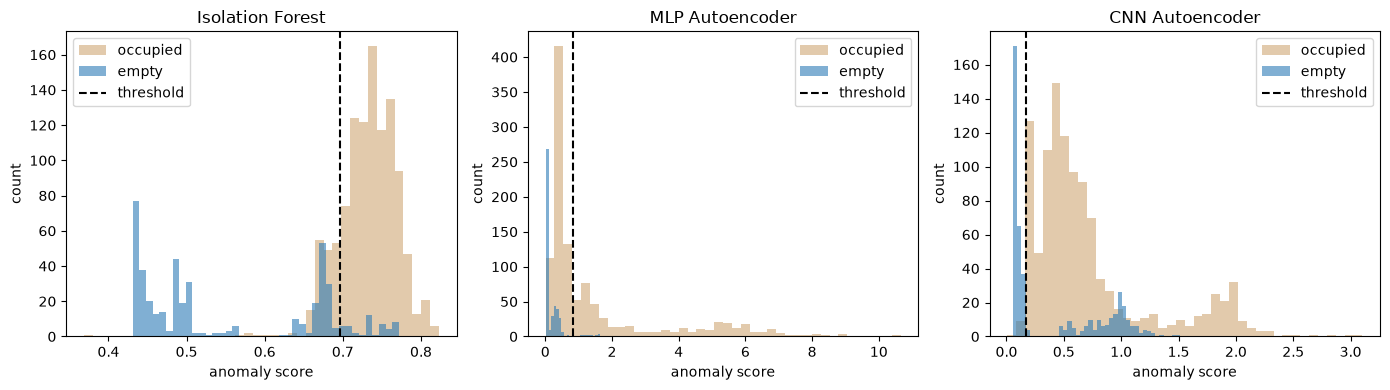

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

colors = {'Isolation Forest': '#2C7BB6',
          'MLP Autoencoder' : '#D97B2B',
          'CNN Autoencoder' : '#4DAF4A'}

for ax, (name, (scores, thresh)) in zip(axes, models.items()):
    ax.hist(scores[y_test==1], bins=40, alpha=0.6, label='occupied', color='#CFA876')
    ax.hist(scores[y_test==0], bins=40, alpha=0.6, label='empty',    color='#2C7BB6')
    ax.axvline(thresh, color='black', linestyle='--', label='threshold')
    ax.set_title(name)
    ax.set_xlabel('anomaly score')
    ax.set_ylabel('count')
    ax.legend()

plt.tight_layout()
plt.savefig('../uci-outputs/05_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

the roc curve shows score separation power independent of threshold. isolation forest (blue) dominates its curve is furthest into the top left corner across almost the entire range. mlp (green) is second. cnn (red) is the most unusual shape it stays low and flat for most of the range then jumps sharply near fpr=0.4. this means the cnn scores are compressed into a narrow band, most windows get similar scores and only at one specific threshold does separation happen. that's why its auc is low even though its f1 at that threshold is high.

## F1 bar chart

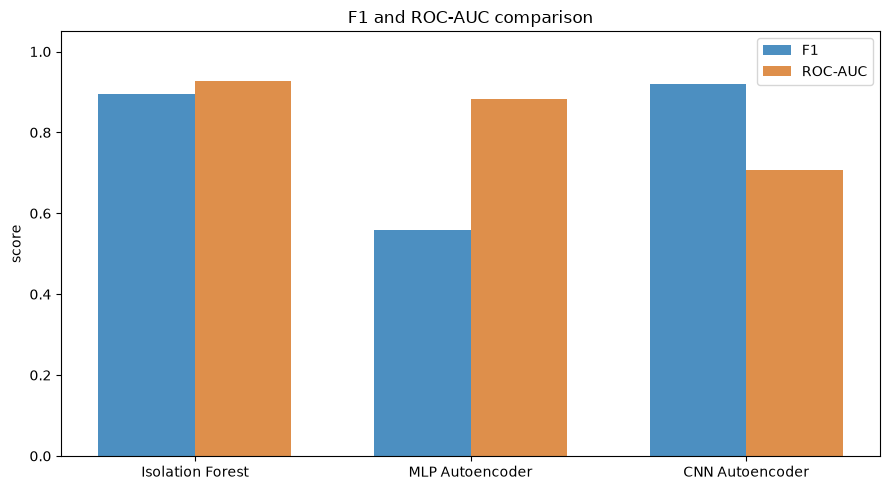

In [5]:
names = list(results.keys())
f1s   = [results[n][2] for n in names]
aucs  = [results[n][3] for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(9,5))
ax.bar(x - width/2, f1s,  width, label='F1',      color='#2C7BB6', alpha=0.85)
ax.bar(x + width/2, aucs, width, label='ROC-AUC', color='#D97B2B', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylim(0, 1.05)
ax.set_ylabel('score')
ax.set_title('F1 and ROC-AUC comparison')
ax.legend(); plt.tight_layout()
plt.savefig('../uci-outputs/05_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

the bar chart makes the f1 vs roc-auc split visible at a glance. cnn has the tallest f1 bar but the shortest roc-auc bar. isolation forest is the most consistent both bars are high and close together. mlp has the worst f1 but its roc-auc is closer to isolation forest than to cnn, which means its scores are actually more informative than its threshold-based predictions suggest the problem is where the threshold lands, not the scores themselves.

for a presence detection application where missing an occupied window is costly (security, energy management), cnn is the right choice. where false alarms are disruptive, isolation forest is more reliable. the best method depends on the deployment context, not just the numbers.

## Conclusions

Three models compared on the same data, same split, same threshold method.

**CNN Autoencoder wins on F1 (0.919)** best at actually detecting presence when you pick a threshold. Recall of 0.988 means it almost never misses an occupied window.

**Isolation Forest wins on ROC-AUC (0.928)** its scores separate the two classes more cleanly across all thresholds, even though its F1 is slightly lower than CNN.

**MLP Autoencoder is the weakest overall.** Flattening the window loses the time structure, so many occupied windows look similar to empty ones in feature space and score below the threshold.

The F1 vs ROC-AUC gap in the CNN result is the most interesting finding. CNN is aggressive it flags a lot, catches almost everything, but generates more false alarms (179 vs 46 for Isolation Forest). Which model is better depends on the use case. In a security or energy management system where missing presence is costly, CNN is the right choice. Where false alarms are disruptive, Isolation Forest is more reliable.

All three methods work without any labeled anomalies during training. The unsupervised one class setup is viable for indoor presence detection from sensor signals.